In [650]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# wczytanie bibliotek


In [651]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
base_path = Path('/content/drive/MyDrive')

# wczytanie danych

In [652]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

Z poprzedniego zadania wiem, że kluczowe dla modeli będą zmienne Pclass oraz Sex

# przygotowanie danych

Wykorzystuję poprzednie zadanie do przygotowania danych. Ze zmiennej Name wyodrębniam nową kolumnę "Title" - tytuł danej osoby, nastepnie usuwam zmienne Name oraz Ticket, które nie przydadzą się do budowy modelu oraz Cabin ze względu na dużą liczbę braków danych


In [653]:
titanic_df["Title"] = titanic_df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
titanic_df["Title"] = titanic_df["Title"].replace(rare_titles, "Rare")
titanic_df["Title"] = titanic_df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
titanic_df["Title"].value_counts()

titanic_df = titanic_df.drop(columns=["Name", "Ticket", "Cabin"])

In [654]:
# dodajemy nowe zmienne, które mogą być przydatne w analizie
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1 # liczba członków rodziny na pokładzie
titanic_df["IsChild"] = titanic_df["Age"] < 18 # czy pasażer jest dzieckiem
titanic_df["IsChild"] = titanic_df["IsChild"].astype("int")

targetowaną kolumną jest survived

In [655]:
X = titanic_df.drop(columns="Survived")
y = titanic_df["Survived"]

dzielimy zbiór na testowy i treningowy

In [656]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

wartości brakujące dla zmiennych Age, Fare i Embarked uzupełniamy wartościami obliczonymi wyłącznie na zbiorze treningowym, aby zapobiec data leakage

In [657]:
age_median = X_train["Age"].median()
fare_median = X_train["Fare"].median()
embarked_mode = X_train["Embarked"].mode()[0]

X_train["Age"] = X_train["Age"].fillna(age_median)
X_train["Fare"] = X_train["Fare"].fillna(fare_median)
X_train["Embarked"] = X_train["Embarked"].fillna(embarked_mode)

X_test["Age"] = X_test["Age"].fillna(age_median)
X_test["Fare"] = X_test["Fare"].fillna(fare_median)
X_test["Embarked"] = X_test["Embarked"].fillna(embarked_mode)

kodowanie zmiennych kategorycznych

In [658]:
X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})
X_test['Sex'] = X_test['Sex'].map({'male': 0, 'female': 1})

X_train["Pclass"] = X_train["Pclass"].astype(int)
X_test["Pclass"] = X_test["Pclass"].astype(int)

X_train = pd.get_dummies(X_train, columns=["Embarked", "Title"], drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=["Embarked", "Title"], drop_first=True, dtype=int)
print(list(X_train.columns) == list(X_test.columns))

True


In [659]:
def evaluate_model(model, X_train, X_test, y_train, y_test): # funkcja do oceny modelu, przyda się do końcowego porównania
  model.fit(X_train, y_train)
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)
  results = { "Train Accuracy": accuracy_score(y_train, y_train_pred),
             "Test Accuracy": accuracy_score(y_test, y_test_pred),
              "Train Precision": precision_score(y_train, y_train_pred, zero_division=0),
              "Test Precision": precision_score(y_test, y_test_pred, zero_division=0),
              "Train Recall": recall_score(y_train, y_train_pred, zero_division=0),
              "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),
              "Train F1": f1_score(y_train, y_train_pred, zero_division=0),
              "Test F1": f1_score(y_test, y_test_pred, zero_division=0) }
  return results

# dummy classifier

jako bazowy klasyfikator wykorzystamy dummy classifier, do niego będziemy porównywać wyniki otrzymane przez nasze modele

In [660]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)

dummy_results = evaluate_model( dummy, X_train, X_test, y_train, y_test )

dummy_train_pred = dummy.predict(X_train)
dummy_test_pred = dummy.predict(X_test)

In [661]:
print("wyniki dummy na zbiorze treningowym")
print(classification_report(y_train, dummy_train_pred, zero_division=0))

print("wyniki dummy na zbiorze testowym")
print(classification_report(y_test, dummy_test_pred, zero_division=0))

print("macierz pomyłek dummy na zbiorze testowym")
print(confusion_matrix(y_test, dummy_test_pred))

wyniki dummy na zbiorze treningowym
              precision    recall  f1-score   support

           0       0.62      1.00      0.76       439
           1       0.00      0.00      0.00       273

    accuracy                           0.62       712
   macro avg       0.31      0.50      0.38       712
weighted avg       0.38      0.62      0.47       712

wyniki dummy na zbiorze testowym
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       110
           1       0.00      0.00      0.00        69

    accuracy                           0.61       179
   macro avg       0.31      0.50      0.38       179
weighted avg       0.38      0.61      0.47       179

macierz pomyłek dummy na zbiorze testowym
[[110   0]
 [ 69   0]]


Do oceny modeli będziemy skupiać się na metryce f1, bo uwzględnia ona jednocześnie zarówno precision jak i recall. Dodatkowo zbadamy też accuracy - dokładność klasyfikacji

# drzewo klasyfikacyjne

Najpierw budujemy model drzewa klasyfikacyjnego z max_depth=3. Jako schemat oceny wykorzystamy 5 fold crossvalidation

In [662]:
tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42)
wyniki = cross_val_score(
    tree,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Wyniki CV F1:", wyniki)
print(f"Średnia: {wyniki.mean():.3f} "
    f"Odchylenie: {wyniki.std():.3f}")

tree_results = evaluate_model(tree, X_train, X_test, y_train, y_test)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

print("wyniki drzewa klasyfikacyjnego na zbiorze treningowym:")
print(classification_report(y_train, y_train_pred))
print(confusion_matrix(y_train, y_train_pred))

print("wyniki drzewa klasyfikacyjnego na zbiorze testowym:")
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

Wyniki CV F1: [0.76785714 0.71287129 0.8490566  0.74074074 0.76      ]
Średnia: 0.766 Odchylenie: 0.046
wyniki drzewa klasyfikacyjnego na zbiorze treningowym:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       439
           1       0.81      0.76      0.78       273

    accuracy                           0.84       712
   macro avg       0.83      0.82      0.83       712
weighted avg       0.84      0.84      0.84       712

[[390  49]
 [ 66 207]]
wyniki drzewa klasyfikacyjnego na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179

[[97 13]
 [18 51]]


Wyniki na zbiorze treningowym i testowym są do siebie mocno zbliżone. oznacza to, że raczej nie doszło do overfittingu

## strojenie hiperparametrów dla drzewa

In [663]:
# siatka hiperparametrów
siatka_tree = {
    "max_depth": [1, 2, 3, 4, 5, 7, None],
    "min_samples_split": [2, 5, 10, 20, 30],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

tree_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=siatka_tree,
    cv=cv,
    scoring="f1",
    return_train_score=True
)

tree_search.fit(
    X_train,
    y_train
)

print("najlepsze ustawienia:", tree_search.best_params_)
print("najlepszy wynik kroswalidacji f1:", round(tree_search.best_score_, 3))

najlepsze ustawienia: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 20}
najlepszy wynik kroswalidacji f1: 0.772


In [664]:
tabela_tree = pd.DataFrame(tree_search.cv_results_)
tabela_tree = tabela_tree[
    [
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "param_criterion",
        "mean_train_score",
        "mean_test_score",
        "std_test_score"
    ]
]

tabela_tree = tabela_tree.sort_values("mean_test_score", ascending=False)
tabela_tree.head(10)

,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_criterion,mean_train_score,mean_test_score,std_test_score
273,None,20,5,entropy,0.826027,0.772262,0.053468
270,None,2,5,entropy,0.856934,0.770932,0.036907
272,None,10,5,entropy,0.856934,0.770932,0.036907
271,None,5,5,entropy,0.856934,0.770932,0.036907
48,3,20,2,gini,0.774149,0.767220,0.044339
43,3,20,1,gini,0.774149,0.767220,0.044339
133,None,20,5,gini,0.821845,0.766487,0.048891
42,3,10,1,gini,0.775634,0.766105,0.045604
41,3,5,1,gini,0.775634,0.766105,0.045604
40,3,2,1,gini,0.775634,0.766105,0.045604


Najlepszy średni wynik kroswalidacji f1 równy ok. 77% uzyskujemy dla parametrów: 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 20. Jednocześnie odchylenie standardowe wyników pomiędzy foldami wynosi ok. 0.05. Dla innych kombinacji, np. przy min_samples_split = 2, uzyskujemy bardzo podobne średnie wyniki przy mniejszym odchyleniu standardowym.

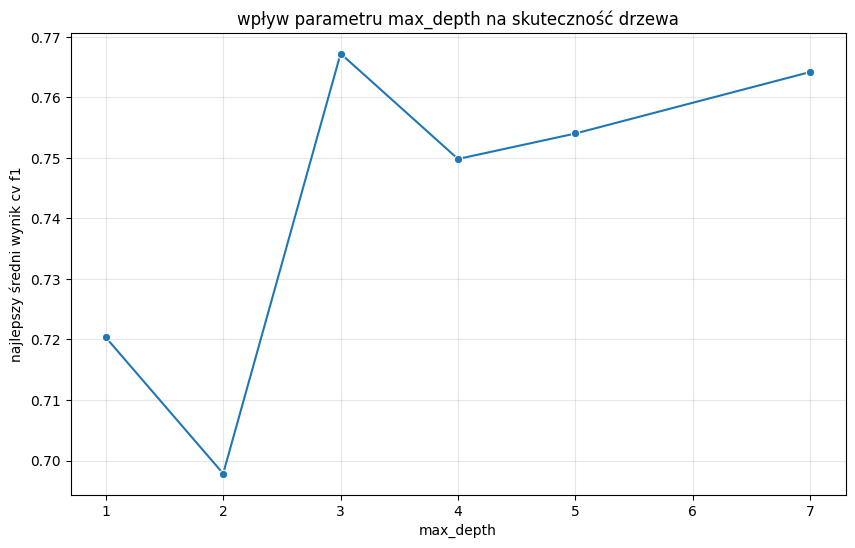

In [665]:
depth_results = (tabela_tree.groupby("param_max_depth")["mean_test_score"].max().reset_index())

plt.figure(figsize=(10, 6))
sns.lineplot(data=depth_results, x="param_max_depth", y="mean_test_score", marker="o")
plt.xlabel("max_depth")
plt.ylabel("najlepszy średni wynik cv f1")
plt.title("wpływ parametru max_depth na skuteczność drzewa")
plt.grid(alpha=0.3)
plt.show()

Najlepszy średni wynik kroswalidacji f1 początkowo spada przy 2, potem gwałtownie rośnie, jednak po osiągnięciu maksimum dla max_depth=3, dalsze zwiększanie nie przynosi już istotnej poprawy

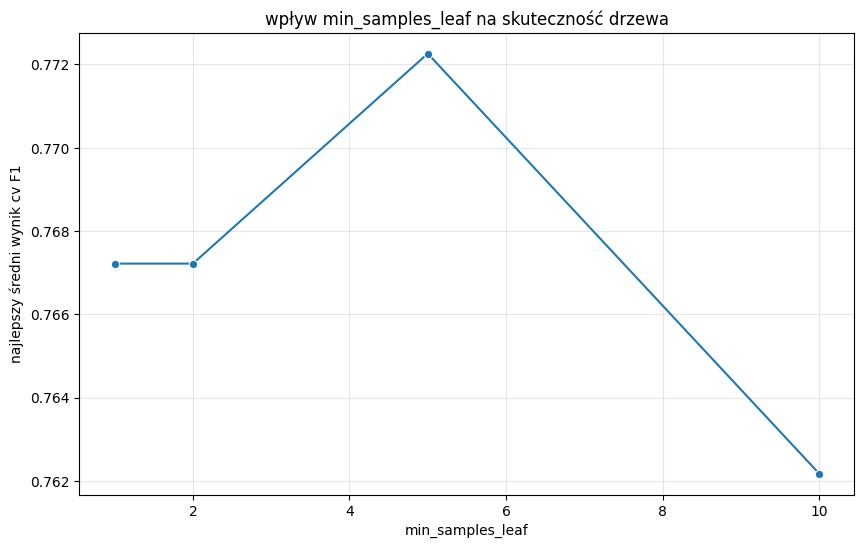

In [666]:
leaf_results = (tabela_tree.groupby("param_min_samples_leaf")["mean_test_score"].max().reset_index())

plt.figure(figsize=(10, 6))
sns.lineplot(data=leaf_results, x="param_min_samples_leaf", y="mean_test_score", marker="o")
plt.xlabel("min_samples_leaf")
plt.ylabel("najlepszy średni wynik cv F1")
plt.title("wpływ min_samples_leaf na skuteczność drzewa")
plt.grid(alpha=0.3)
plt.show()

Najlepszy średni wynik f1 osiąga maksimum w 5, a potem maleje w badanym przez nas zakresie

Teraz budujemy drzewo klasyfikacyjne z optymalnymi parametrami

In [667]:
best_tree = tree_search.best_estimator_
tree_train_pred = best_tree.predict(X_train)
tree_test_pred = best_tree.predict(X_test)
best_tree_results = evaluate_model(best_tree, X_train, X_test, y_train, y_test)

In [668]:
print("wyniki drzewa na zbiorze treningowym")
print(classification_report(y_train,tree_train_pred))

print("wyniki drzewa na zbiorze testowym")
print(classification_report(y_test, tree_test_pred))

print("macierz pomyłek na zbiorze testowym")
print(confusion_matrix(y_test, tree_test_pred))

wyniki drzewa na zbiorze treningowym
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       439
           1       0.93      0.75      0.83       273

    accuracy                           0.88       712
   macro avg       0.90      0.86      0.87       712
weighted avg       0.89      0.88      0.88       712

wyniki drzewa na zbiorze testowym
              precision    recall  f1-score   support

           0       0.80      0.92      0.85       110
           1       0.83      0.62      0.71        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179

macierz pomyłek na zbiorze testowym
[[101   9]
 [ 26  43]]


Model z dobranymi parametrami osiąga skuteczność klasfikacji 88% na zbiorze treningowym, 80% na testowym. Różnica 8 punktów procentowych może oznaczać, że doszło do lekkiego przeuczenia

# kNN

W przypadku algorytmu kNN zastosujemy standaryzację danych, ponieważ dla naszego zbioru danych cechy o dużych zakresach liczbowych (np. Fare) zdominowałyby cechy o małych zakresach (np. Pclass czy Sex)

## kNN i strojenie hiperparametrów

In [669]:
knn = KNeighborsClassifier()

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())])

# siatka hiperparametrów
siatka_knn = {
    "knn__n_neighbors": range(1, 31),
    "knn__weights": ["uniform", "distance"]
}

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=siatka_knn,
    cv=cv,
    scoring="f1",
    return_train_score=True
)

knn_search.fit(X_train, y_train)
print("najlepsze parametry:", knn_search.best_params_)
print("najlepszy wynik CV f1:", round(knn_search.best_score_, 3))

najlepsze parametry: {'knn__n_neighbors': 22, 'knn__weights': 'uniform'}
najlepszy wynik CV f1: 0.76


Najlepszy średni wynik kroswalidacji f1 równy 76% dostajemy dla liczby sąsiadów równej 22 i weights=uniform

In [670]:
knn_tuning = pd.DataFrame(knn_search.cv_results_)

knn_tuning = knn_tuning[ [
    "param_knn__n_neighbors",
    "param_knn__weights",
    "mean_train_score",
    "mean_test_score",
    "std_test_score" ] ].sort_values( "mean_test_score", ascending=False )

knn_tuning.head(10)

,param_knn__n_neighbors,param_knn__weights,mean_train_score,mean_test_score,std_test_score
42,22,uniform,0.764941,0.759733,0.045964
46,24,uniform,0.769848,0.759072,0.040821
4,3,uniform,0.841244,0.757155,0.034715
50,26,uniform,0.765676,0.757070,0.045718
48,25,uniform,0.767682,0.755689,0.046952
40,21,uniform,0.764474,0.755377,0.045882
52,27,uniform,0.761809,0.754835,0.047231
36,19,uniform,0.758663,0.753489,0.051266
54,28,uniform,0.760270,0.752825,0.052099
38,20,uniform,0.761610,0.752136,0.049049


Ponownie widzimy, że najlepszy wynik kroswalidacji f1 równy ok. 76% uzyskujemy dla k=22 i weights=uniform. Odchylenie standardowe wyników pomiędzy foldami wynosi 0.046, co oznacza że model działa dość stabilnie

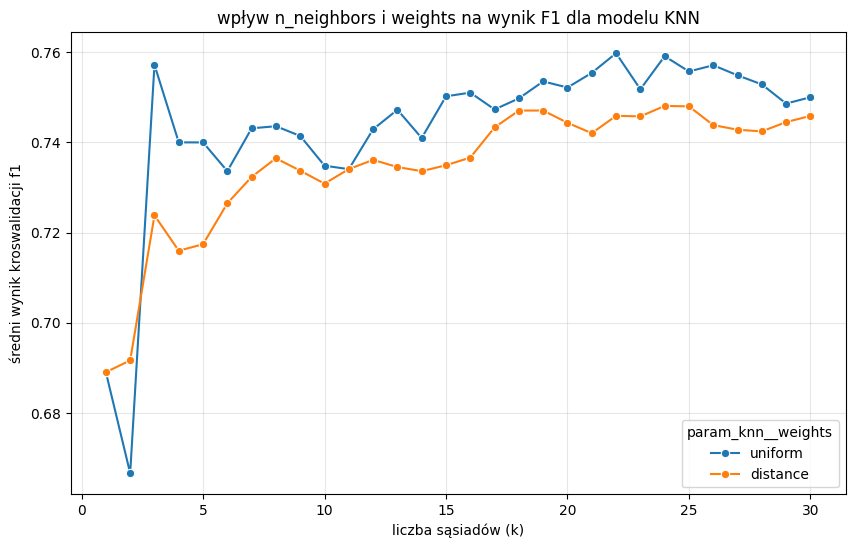

In [671]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=knn_tuning, x="param_knn__n_neighbors", y="mean_test_score", hue="param_knn__weights", marker="o")
plt.xlabel("liczba sąsiadów (k)")
plt.ylabel("średni wynik kroswalidacji f1")
plt.title("wpływ n_neighbors i weights na wynik F1 dla modelu KNN")
plt.grid(alpha=0.3)
plt.show()

Widzimy, że dobrym wyborem jest również k=3 i weights=uniform. Najlepszy średni wynik osiągamy jednak dla k=22 i weights=uniform. Ogólnie wyższe wyniki osiągamy dla weights=uniform niż distance. Teraz zbudujemy model oparty już na dostrojonych parametrach

In [672]:
best_knn = knn_search.best_estimator_

knn_train_pred = best_knn.predict(X_train)
knn_test_pred = best_knn.predict(X_test)

print("wyniki KNN na zbiorze treningowym:")
print(classification_report(y_train, knn_train_pred))

print("wyniki KNN na zbiorze testowym:")
print(classification_report(y_test, knn_test_pred))

print("macierz pomyłek na zbiorze testowym:")
print(confusion_matrix(y_test, knn_test_pred))
final_knn_results = evaluate_model( best_knn, X_train, X_test, y_train, y_test )

wyniki KNN na zbiorze treningowym:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       439
           1       0.84      0.69      0.76       273

    accuracy                           0.83       712
   macro avg       0.83      0.81      0.81       712
weighted avg       0.83      0.83      0.83       712

wyniki KNN na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88       110
           1       0.86      0.70      0.77        69

    accuracy                           0.84       179
   macro avg       0.84      0.81      0.82       179
weighted avg       0.84      0.84      0.83       179

macierz pomyłek na zbiorze testowym:
[[102   8]
 [ 21  48]]


Model knn z dobranymi optymalnymi parametrami osiąga skuteczność klasyfikacji 83% na zbiorze treningowym, a na testowym 84%. Wynik na testowym jest nieznacznie wyższy niż na treningowym. Oznacza to, że raczej nie doszło do przeuczenia modelu

# porównanie modeli na zbiorze testowym

In [673]:
comparison = pd.DataFrame([
    {"Model": "Dummy", **dummy_results},
    {"Model": "Classification Tree", **best_tree_results},
    {"Model": "kNN", **final_knn_results}])
print(comparison[["Model",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1"]])

                 Model  Test Accuracy  Test Precision  Test Recall   Test F1
0                Dummy       0.614525        0.000000     0.000000  0.000000
1  Classification Tree       0.804469        0.826923     0.623188  0.710744
2                  kNN       0.837989        0.857143     0.695652  0.768000


Na zbiorze testowym najlepszym spośród modeli okazał się być kNN (z dobranymi parametrami k=22 i weights=uniform), osiągnął on wynik f1 76.8% oraz accuracy równe 83.8%. kNN osiąga jednak Recall równy 69.6%, który jest niższy w porównaniu do wyższego Precision równego 85.7%, oznacza to, że model rzadko fałszywie klasyfikuje pasażera jako ocalałego, ale radzi sobie gorzej z poprawnym klasyfikowaniem ocalałych pasażerów. Drzewo klasyfikacyjne osiąga jednak wyższy Recall niż kNN. Oba modele, drzewo klasyfikacyjne i kNN, osiągnęły znacznie wyższe wyniki niż Dummy Classifier, którego accuracy wynosi 61% (dokładnie tyle, ilu pasażerów zginęło). Jego wynik f1 wynosi 0, bo nigdy nie przewiduje on, że pasażer przeżył.